# Use AutoAI and timeseries data to predict COVID19 cases with `ibm-watsonx-ai`

This notebook contains the steps and code to demonstrate support of AutoAI experiments for timeseries data sets in watsonx.ai service. It introduces commands for data retrieval, training experiments, persisting pipelines, testing pipelines, deploying pipelines, and scoring.

Some familiarity with Python is helpful. This notebook uses Python 3.12.


## Learning goals

The learning goals of this notebook are:

-  Define watsonx.ai AutoAI experiment for timeseries data sets. 
-  Work with experiments to train AutoAI models.
-  Compare trained models quality and select the best one for further deployment.
-  Online deployment and score the trained model.


## Contents

This notebook contains the following parts:

1. [Set up the environment](#1.-Set-up-the-environment)
2. [Timeseries data set](#2.-Timeseries-data-set)
3. [Optimizer definition](#3.-Optimizer-definition)
4. [Experiment run](#4.-Experiment-run)
5. [Pipelines comparison](#5.-Pipelines-comparison)
6. [Deploy and Score](#6.-Deploy-and-Score)
7. [Cleanup](#7.-Cleanup)
8. [Summary and next steps](#8.-Summary-and-next-steps)

<a id="1.-Set-up-the-environment"></a>
## 1. Set up the environment

Before you use the sample code in this notebook, you must perform the following setup tasks:

-  Contact with your IBM Cloud Pak® for Data administrator and ask them for your account credentials

### Install dependencies
**Note:** `ibm-watsonx-ai` documentation can be found <a href="https://ibm.github.io/watsonx-ai-python-sdk/index.html" target="_blank" rel="noopener no referrer">here</a>.

In [1]:
%pip install wget | tail -n 1
%pip install -U ibm-watsonx-ai | tail -n 1
%pip install -U matplotlib | tail -n 1
%pip install -U tqdm | tail -n 1

#### Define credentials

Authenticate the watsonx.ai Runtime service on IBM Cloud Pak® for Data. You need to provide the **admin's** `username` and the platform `url`.

In [2]:
username = "PASTE YOUR USERNAME HERE"
url = "PASTE THE PLATFORM URL HERE"

Use the **admin's** `api_key` to authenticate watsonx.ai Runtime services:

In [ ]:
import getpass

from ibm_watsonx_ai import Credentials

credentials = Credentials(
    username=username,
    api_key=getpass.getpass("Enter your watsonx.ai API key and hit enter: "),
    url=url,
    instance_id="openshift",
    version="5.4",
)

Alternatively you can use the **admin's** `password`:

In [3]:
import getpass

from ibm_watsonx_ai import Credentials

if "credentials" not in locals() or not credentials.api_key:
    credentials = Credentials(
        username=username,
        password=getpass.getpass("Enter your watsonx.ai password and hit enter: "),
        url=url,
        instance_id="openshift",
        version="5.4",
    )

#### Create `APIClient` instance

In [4]:
from ibm_watsonx_ai import APIClient

client = APIClient(credentials)

### Working with spaces

First of all, you need to create a space that will be used for your work. If you do not have space already created, you can use `{PLATFORM_URL}/ml-runtime/spaces?context=icp4data` to create one.

- Click New Deployment Space
- Create an empty space
- Go to space `Settings` tab
- Copy `space_id` and paste it below

**Tip**: You can also use SDK to prepare the space for your work. More information can be found [here](https://github.com/IBM/watsonx-ai-samples/blob/master/cpd5.4/notebooks/python_sdk/instance-management/Space%20management.ipynb).

**Action**: Assign space ID below

In [ ]:
space_id = "PASTE YOUR SPACE ID HERE"

You can use the `list` method to print all existing spaces.

In [ ]:
client.spaces.list(limit=10)

To be able to interact with all resources available in watsonx.ai, you need to set the **space** which you will be using.

In [6]:
client.set.default_space(space_id)

'SUCCESS'

<a id="2.-Timeseries-data-set"></a>
## 2. Timeseries data set

### Training data sets

Define connection information to training data CSV file.  
This example uses the [Poland COVID19 daily confirmed cases](https://raw.githubusercontent.com/LukaszCmielowski/covid-19/master/poland_daily_cases_03_28_2021.csv).

In [7]:
import os

import wget

filename = "poland_daily_cases_03_28_2021.csv"
base_url = "https://raw.githubusercontent.com/LukaszCmielowski/covid-19/master/"

if not os.path.isfile(filename):
    wget.download(base_url + filename)

In [8]:
asset_details = client.data_assets.create("poland_daily_cases_03_28_2021.csv", filename)
asset_details

Creating data asset...
SUCCESS


{'metadata': {'space_id': 'b8dbde51-f58b-48ac-bbad-784aa59938c9',
  'usage': {'last_updated_at': '2026-04-21T11:07:08Z',
   'last_updater_id': '1000331001',
   'last_update_time': 1776769628750,
   'last_accessed_at': '2026-04-21T11:07:08Z',
   'last_access_time': 1776769628750,
   'last_accessor_id': '1000331001',
   'access_count': 0},
  'rov': {'mode': 0,
   'collaborator_ids': {},
   'member_roles': {'1000331001': {'user_iam_id': '1000331001',
     'roles': ['OWNER']}}},
  'is_linked_with_sub_container': False,
  'name': 'poland_daily_cases_03_28_2021.csv',
  'description': '',
  'asset_type': 'data_asset',
  'origin_country': 'us',
  'resource_key': 'poland_daily_cases_03_28_2021.csv',
  'rating': 0.0,
  'total_ratings': 0,
  'catalog_id': '534260a2-373f-4b19-b17e-62dc546c349d',
  'created': 1776769628750,
  'created_at': '2026-04-21T11:07:08Z',
  'owner_id': '1000331001',
  'size': 0,
  'version': 2.0,
  'asset_state': 'available',
  'asset_attributes': ['data_asset'],
  'asset_i

In [9]:
client.data_assets.get_id(asset_details)

'9038bbf6-92a7-4bbd-b1bf-ed3e79b7cb81'

In [10]:
from ibm_watsonx_ai.helpers import DataConnection

covid_daily_cases = DataConnection(
    data_asset_id=client.data_assets.get_id(asset_details)
)

training_data_reference = [covid_daily_cases]

### Visualize the data

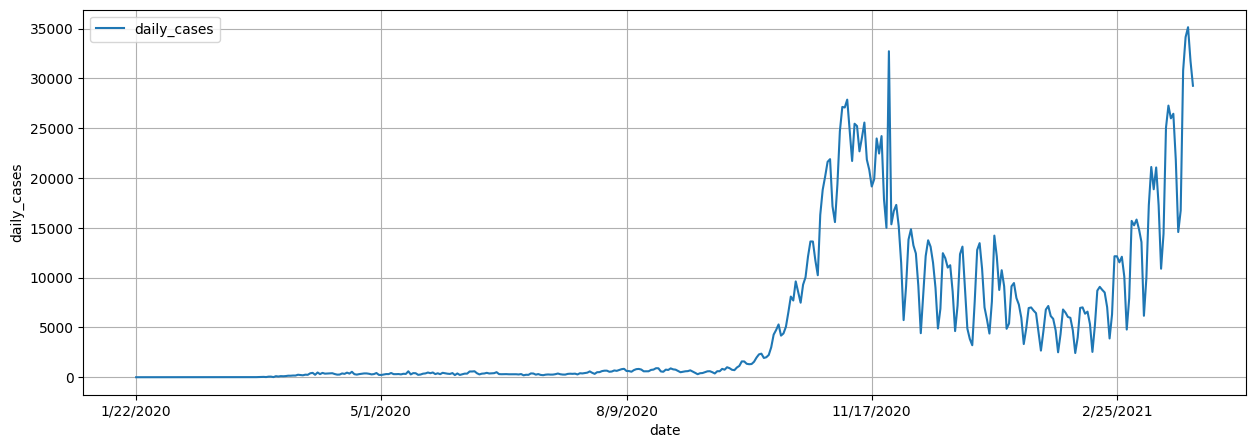

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(filename)
df.plot(x="date", y="daily_cases", figsize=(15, 5))
plt.ylabel(ylabel="daily_cases")
plt.grid()
plt.legend()
plt.show()

<a id="3.-Optimizer-definition"></a>
## 3. Optimizer definition

### Optimizer configuration

Provide the input information for AutoAI optimizer:
- `name` - experiment name
- `prediction_type` - type of the problem
- `prediction_columns` - target columns names
- `scoring` - optimization metric

In [12]:
from ibm_watsonx_ai.experiment import AutoAI

experiment = AutoAI(credentials, space_id=space_id)
forecast_window = 7

pipeline_optimizer = experiment.optimizer(
    name="COVID19 PL timeseries",
    prediction_type=AutoAI.PredictionType.FORECASTING,
    prediction_columns=["daily_cases"],
    timestamp_column_name=0,
    scoring=AutoAI.Metrics.R2_SCORE,
    max_number_of_estimators=1,
    backtest_num=4,
    lookback_window=5,
    forecast_window=forecast_window,
    holdout_size=5,
)

Configuration parameters can be retrieved via `pipeline_optimizer.get_params()`.

<a id="4.-Experiment-run"></a>
## 4. Experiment run

Call the `fit()` method to trigger the AutoAI experiment. You can either use interactive mode (synchronous job) or background mode (asychronous job) by specifying `background_model=True`.

In [13]:
fit_details = pipeline_optimizer.fit(
    training_data_reference=training_data_reference, background_mode=False
)

Training job 4f187714-923e-49b4-b438-f238e0441f6f completed: 100%|████████| [00:57<00:00,  1.74it/s]


You can use the `get_run_status()` method to monitor AutoAI jobs in background mode.

In [14]:
pipeline_optimizer.get_run_status()

'completed'

<a id="5.-Pipelines-comparison"></a>
## 5. Pipelines comparison

You can list trained pipelines and evaluation metrics information in
the form of a Pandas DataFrame by calling the `summary()` method. You can
use the DataFrame to compare all discovered pipelines and select the one
you like for further deployment.

In [15]:
summary = pipeline_optimizer.summary()
summary

,Enhancements,Estimator,Winner,validation_symmetric_mean_absolute_percentage_error,holdout_avg_r2,holdout_avg_mean_absolute_error,holdout_avg_root_mean_squared_error,holdout_avg_symmetric_mean_absolute_percentage_error,holdout_mean_absolute_error,holdout_root_mean_squared_error,holdout_symmetric_mean_absolute_percentage_error,holdout_r2,backtest_avg_r2,backtest_avg_mean_absolute_error,backtest_avg_root_mean_squared_error,backtest_avg_symmetric_mean_absolute_percentage_error,backtest_mean_absolute_error,backtest_root_mean_squared_error,backtest_symmetric_mean_absolute_percentage_error,backtest_r2
Pipeline Name,,,,,,,,,,,,,,,,,,,,
Pipeline_6,"HPO, FE",Ensembler,True,28.031457,-21.05751,9994.500147,10123.154738,36.81724,9994.500147,10123.154738,36.81724,-21.05751,0.042897,3538.269264,4011.517396,22.172355,3538.269264,4011.517396,22.172355,0.042897


Check pipeline details by calling `get_pipeline_details(pipeline_name='Pipeline_6')`. By default details of best pipeline are returned.

In [16]:
best_pipeline_name = summary[summary.Winner == True].index.values[0]
print("Best pipeline is:", best_pipeline_name)

pipeline_details = pipeline_optimizer.get_pipeline_details()

Best pipeline is: Pipeline_6


### Holdout data visualization

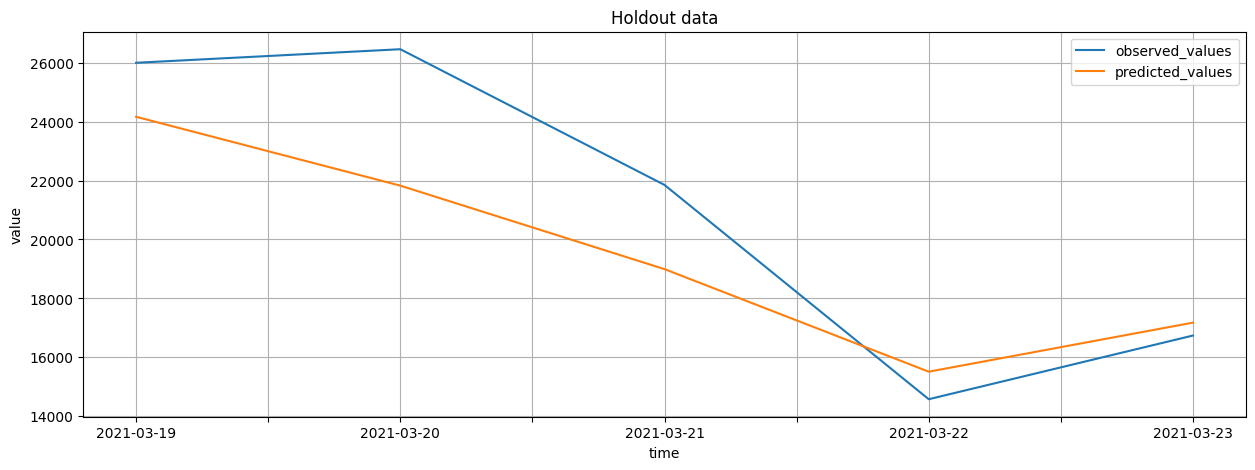

In [17]:
from datetime import datetime, timedelta

import numpy as np

visualization = pipeline_details["visualization"]["backtest"]["iterations"][-1]
holdout_dates = visualization["time"]
holdout_predictions = visualization["predicted_values"][0]
observed_values = visualization["observed_values"][0]
holdout_df = pd.DataFrame(
    {
        "time": holdout_dates,
        "observed_values": observed_values,
        "predicted_values": holdout_predictions,
    }
)

holdout_df.plot(x="time", title="Holdout data", figsize=(15, 5))
plt.ylabel(ylabel="value")
plt.grid()
plt.legend()
plt.show()

<a id="6.-Deploy-and-Score"></a>
## 6. Deploy and Score

In this section you will learn how to deploy and score pipeline model as online deployment using WML instance.

### Online deployment creation

In [18]:
from ibm_watsonx_ai.deployment import WebService

service = WebService(credentials, source_space_id=space_id)

service.create(
    experiment_run_id=pipeline_optimizer.get_run_details()["metadata"]["id"],
    model=best_pipeline_name,
    deployment_name="COVID19 for Poland",
)

Preparing an AutoAI Deployment...
Published model uid: 3e24effb-d6d7-4927-a5c0-8706a72e9f7a
Deploying model 3e24effb-d6d7-4927-a5c0-8706a72e9f7a using V4 client.


######################################################################################

Synchronous deployment creation for id: '3e24effb-d6d7-4927-a5c0-8706a72e9f7a' started

######################################################################################


initializing
Note: online_url is deprecated and will be removed in a future release. Use serving_urls instead.
....
ready


-----------------------------------------------------------------------------------------------
Successfully finished deployment creation, deployment_id='d71c2dfb-eef0-4dd1-92d1-a3abb087e41a'
-----------------------------------------------------------------------------------------------




To show all available information about the deployment use the `.get_params()` method:

In [ ]:
service.get_params()

### Scoring

You can use the `score` method to get predictions for defined forecasting window. You can either send payload records or use empty list.

In [20]:
predictions = service.score(payload=pd.DataFrame({"daily_cases": []}))
print("predictions for next 7 days:\n")
predictions

predictions for next 7 days:



{'predictions': [{'fields': ['prediction'],
   'values': [[[19904.816700229545]],
    [[22106.556234812087]],
    [[24501.057719609922]],
    [[24280.056249000198]],
    [[20357.0123610303]],
    [[15169.625869179024]],
    [[14853.03013917623]]]}]}

Or you could send payload with new obeservations:

```
predictions = service.score(payload=pd.DataFrame({'daily_cases' : df.iloc[-10:, 1].values.tolist()}))
```

### Visualization of predictions

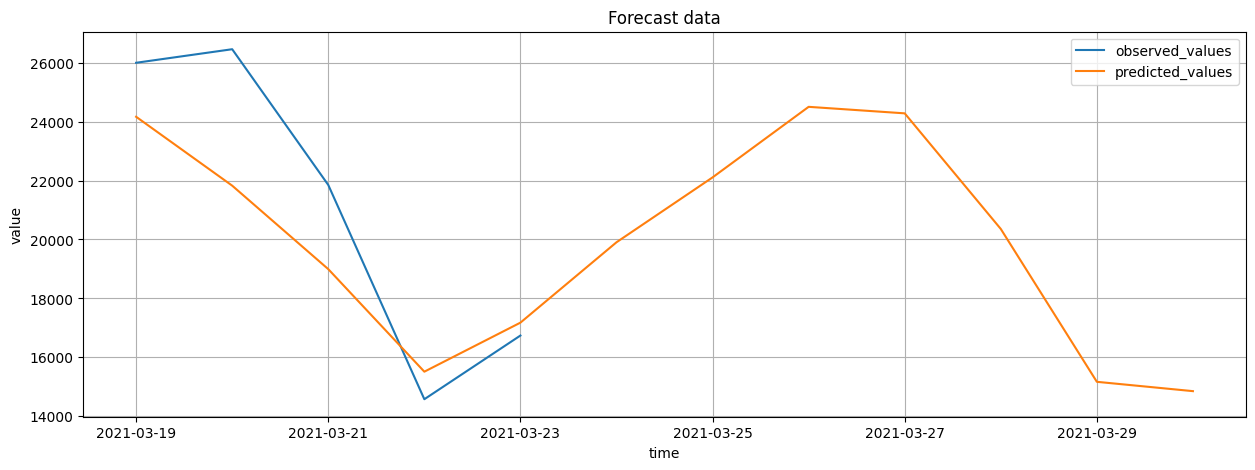

In [21]:
last_date = datetime.strptime(holdout_df.tail(1).time.values.tolist()[0], "%Y-%m-%d")
prediction_dates = [
    (last_date + timedelta(days=1 + i)).date() for i in range(forecast_window)
]

prediction_values = [pred[0][0] for pred in predictions["predictions"][0]["values"]]

pred_df = pd.DataFrame(
    {
        "time": holdout_dates + prediction_dates,
        "observed_values": observed_values + [np.nan for _ in range(forecast_window)],
        "predicted_values": holdout_predictions + prediction_values,
    }
)

pred_df.plot(x="time", title="Forecast data", figsize=(15, 5))
plt.ylabel(ylabel="value")
plt.grid()
plt.legend()
plt.show()

<a id="7.-Cleanup"></a>
## 7. Cleanup

If you want to clean up all created assets:
- experiments
- trainings
- pipelines
- model definitions
- models
- functions
- deployments

please follow up this sample [notebook](https://github.com/IBM/watsonx-ai-samples/blob/master/cpd5.4/notebooks/python_sdk/instance-management/Machine%20Learning%20artifacts%20management.ipynb).

<a id="8.-Summary-and-next-steps"></a>
## 8. Summary and next steps

You successfully completed this notebook!
 
You learned how to use `watsonx.ai` to run AutoAI experiments. 
 
Check out our _<a href="https://ibm.github.io/watsonx-ai-python-sdk/samples.html" target="_blank" rel="noopener no referrer">Online Documentation</a>_ for more samples, tutorials, documentation, how-tos, and blog posts. 

### Authors

**Lukasz Cmielowski**, PhD, is an Automation Architect and Data Scientist at IBM with a track record of developing enterprise-level applications that substantially increases clients' ability to turn data into actionable knowledge.


Copyright © 2020-2026 IBM. This notebook and its source code are released under the terms of the MIT License.